# Task 3: Occasion and Gender Classification


## 1. Introduction

This notebook addresses **Task 3: Occasion and Gender Classification** for Assignment 2 by predicting the catalogue gender category and intended occasion of a fashion product from its RGB image. The task is formulated as **two separate multi-class classification problems: one model predicts gender and another predicts occasion (the metadata field `usage`)**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The CNN family includes three declared architecture/scheduling configurations.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Gender labels describe the catalogue category rather than the identity of a person in an image. Occasion labels may overlap visually, and frequent categories can dominate accuracy. Each target is trained, compared, and evaluated separately.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Numerical findings and the final model judgment must be completed from the new executed results; no winner is assumed in advance.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.


In [1]:
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models', ROOT / 'results', ROOT / 'figures')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target
get_ipython().run_line_magic('matplotlib', 'inline')

# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False


2026-09-11 10:53:08.502386: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 10:53:08.566792: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-11 10:53:09.541032: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.


In [2]:
metadata_by_target = {'gender': task_frame('gender'), 'usage': task_frame('usage')}
frame = metadata_by_target['gender']
print('gender', frame.shape)
display(frame.head())
frame = metadata_by_target['usage']
print('usage', frame.shape)
display(frame.head())

gender (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


usage (38610, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.


### 4.1. Class Distribution & Balancing Strategy

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.


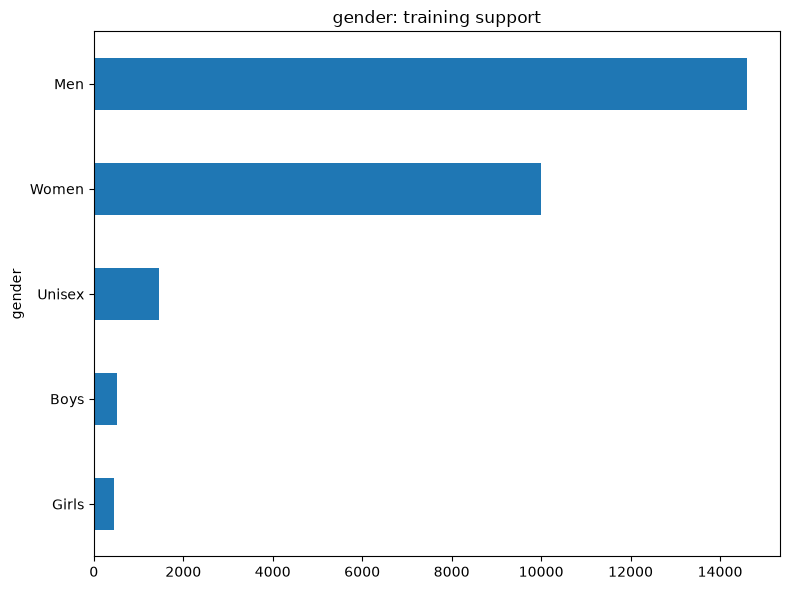

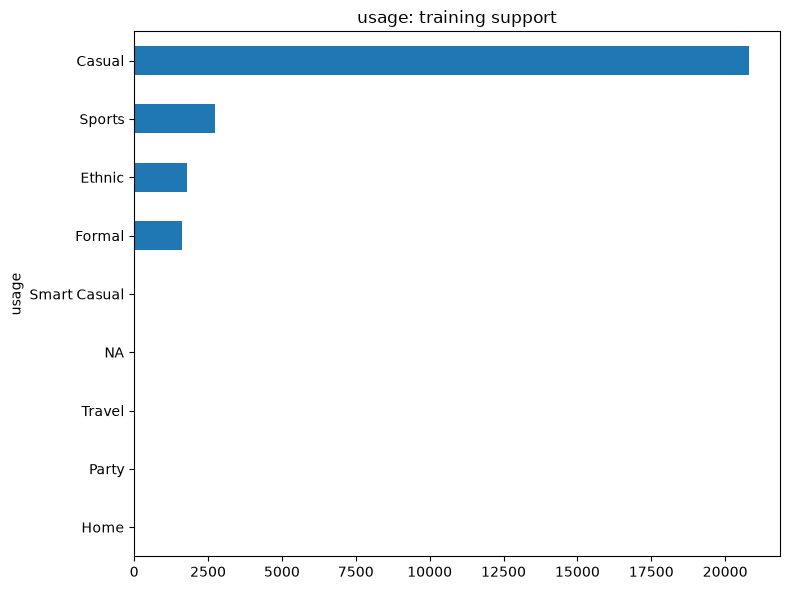

In [3]:
train_rows = metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')]
counts = train_rows['gender'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'gender'}: training support")
plt.tight_layout()
plt.show()
train_rows = metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')]
counts = train_rows['usage'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'usage'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.


In [3]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [4]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('validation')])
frames['gender'] = dict(train=metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['gender'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['gender'] = sorted(frames['gender']['train']['gender'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['gender'].items()}, name='gender'))
selection, calibration, policy = validation_views(metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('validation')])
frames['usage'] = dict(train=metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['usage'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['usage'] = sorted(frames['usage']['train']['usage'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['usage'].items()}, name='usage'))

train          27051
selection       2900
calibration     1378
policy          1564
Name: gender, dtype: int64

train          27050
selection       2900
calibration     1378
policy          1564
Name: usage, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.


In [5]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.


In [6]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['gender']
loaders['gender'] = {name: CachedBatches(frames['gender'][name], 'gender', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}
labels = labels_by_target['usage']
loaders['usage'] = {name: CachedBatches(frames['usage'][name], 'usage', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}

## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. All candidates use the same image size, normalization, batch size, training/selection groups, Adam optimizer, and maximum epoch budget. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.


In [7]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.


In [8]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [9]:
models = {'gender': {}, 'usage': {}}
histories = {'gender': {}, 'usage': {}}

### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [11]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['gender']['shallow_mlp'].summary()
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['usage']['shallow_mlp'].summary()

I0000 00:00:1789086842.729092  158159 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,438,725 (36.01 MB)

 Trainable params: 9,438,725 (36.01 MB)

...

Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,439,753 (36.01 MB)

 Trainable params: 9,439,753 (36.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [12]:
model = models['gender']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
model = models['usage']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])

#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [13]:
loaders['gender']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['gender']['shallow_mlp'].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['gender']['shallow_mlp'] = pd.DataFrame(fitted.history)
display(histories['gender']['shallow_mlp'].tail())
loaders['usage']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['usage']['shallow_mlp'].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['usage']['shallow_mlp'] = pd.DataFrame(fitted.history)
display(histories['usage']['shallow_mlp'].tail())

Epoch 1/30
423/423 - 12s - 29ms/step - accuracy: 0.7285 - loss: 1.6475 - macro_f1: 0.3541 - val_accuracy: 0.7583 - val_loss: 0.8825 - val_macro_f1: 0.3292
Epoch 2/30
423/423 - 11s - 26ms/step - accuracy: 0.7693 - loss: 0.8160 - macro_f1: 0.3646 - val_accuracy: 0.7876 - val_loss: 0.5666 - val_macro_f1: 0.3820
Epoch 3/30
423/423 - 11s - 25ms/step - accuracy: 0.7774 - loss: 0.8102 - macro_f1: 0.3925 - val_accuracy: 0.7645 - val_loss: 0.9117 - val_macro_f1: 0.3597
Epoch 4/30
423/423 - 11s - 25ms/step - accuracy: 0.7875 - loss: 0.8797 - macro_f1: 0.4327 - val_accuracy: 0.7855 - val_loss: 0.5891 - val_macro_f1: 0.4459
Epoch 5/30
423/423 - 11s - 25ms/step - accuracy: 0.8052 - loss: 0.5494 - macro_f1: 0.5223 - val_accuracy: 0.8200 - val_loss: 0.5634 - val_macro_f1: 0.6405
Epoch 6/30
423/423 - 11s - 25ms/step - accuracy: 0.8014 - loss: 0.7056 - macro_f1: 0.4727 - val_accuracy: 0.8086 - val_loss: 0.9174 - val_macro_f1: 0.4613
Epoch 7/30
423/423 - 11s - 26ms/step - accuracy: 0.8060 - loss: 0.5925

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
7,0.807253,0.718516,0.503490,0.818276,0.644691,0.547673
8,0.818380,0.542340,0.563973,0.820690,0.623818,0.632259
9,0.815053,0.589146,0.568295,0.820000,0.556465,0.550178
10,0.818306,0.556876,0.567050,0.815172,0.570559,0.581302
11,0.815571,0.817035,0.567621,0.786207,0.925479,0.430630


Epoch 1/30
423/423 - 12s - 28ms/step - accuracy: 0.7738 - loss: 1.7536 - macro_f1: 0.2257 - val_accuracy: 0.8248 - val_loss: 0.7963 - val_macro_f1: 0.2874
Epoch 2/30
423/423 - 11s - 26ms/step - accuracy: 0.8038 - loss: 0.8860 - macro_f1: 0.2487 - val_accuracy: 0.8283 - val_loss: 0.7580 - val_macro_f1: 0.2870
Epoch 3/30
423/423 - 11s - 26ms/step - accuracy: 0.8143 - loss: 0.9033 - macro_f1: 0.2624 - val_accuracy: 0.8397 - val_loss: 0.7187 - val_macro_f1: 0.3283
Epoch 4/30
423/423 - 11s - 26ms/step - accuracy: 0.8218 - loss: 0.9550 - macro_f1: 0.2752 - val_accuracy: 0.8152 - val_loss: 0.9181 - val_macro_f1: 0.2778
Epoch 5/30
423/423 - 11s - 27ms/step - accuracy: 0.8260 - loss: 0.7058 - macro_f1: 0.2785 - val_accuracy: 0.8490 - val_loss: 1.0519 - val_macro_f1: 0.3454
Epoch 6/30
423/423 - 11s - 26ms/step - accuracy: 0.8322 - loss: 0.7795 - macro_f1: 0.2960 - val_accuracy: 0.8410 - val_loss: 0.7750 - val_macro_f1: 0.3456
Epoch 7/30
423/423 - 11s - 26ms/step - accuracy: 0.8330 - loss: 0.7388

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
8,0.837006,0.611110,0.291757,0.840690,0.709032,0.322846
9,0.841109,0.556968,0.299538,0.850345,0.975705,0.341143
10,0.844030,0.543034,0.304134,0.844828,0.717507,0.341475
11,0.845102,0.573794,0.309421,0.851724,0.838833,0.342626
12,0.837782,0.763055,0.293164,0.817586,3.260759,0.284965


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender shallow_mlp


selection_accuracy    0.820000
selection_macro_f1    0.640456
dtype: float64

,precision,recall,f1-score,support
Boys,0.820000,0.546667,0.656000,75.00
Girls,0.521739,0.470588,0.494845,51.00
Men,0.851503,0.896402,0.873376,1612.00
Unisex,0.812500,0.242236,0.373206,161.00
Women,0.782814,0.828172,0.804854,1001.00
accuracy,0.820000,0.820000,0.820000,0.82
macro avg,0.757711,0.596813,0.640456,2900.00
weighted avg,0.819014,0.820000,0.809677,2900.00


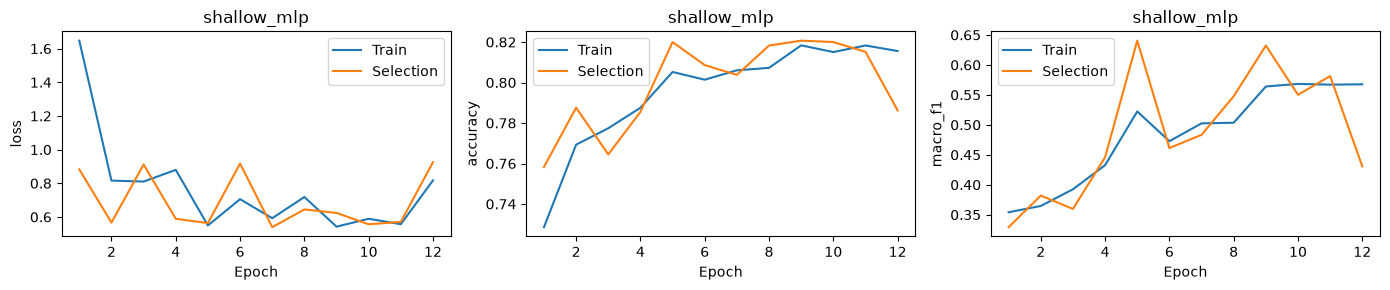

In [14]:
# Gender
loader = loaders['gender']['selection']
for method in ['shallow_mlp']:
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('gender')}_{method}_learning_curves.png", dpi=160)
    plt.show()

usage shallow_mlp


selection_accuracy    0.841034
selection_macro_f1    0.345638
dtype: float64

,precision,recall,f1-score,support
Casual,0.872234,0.933840,0.901986,2237.000000
Ethnic,0.624309,0.680723,0.651297,166.000000
Formal,0.782313,0.646067,0.707692,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.689266,0.397394,0.504132,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.841034,0.841034,0.841034,0.841034


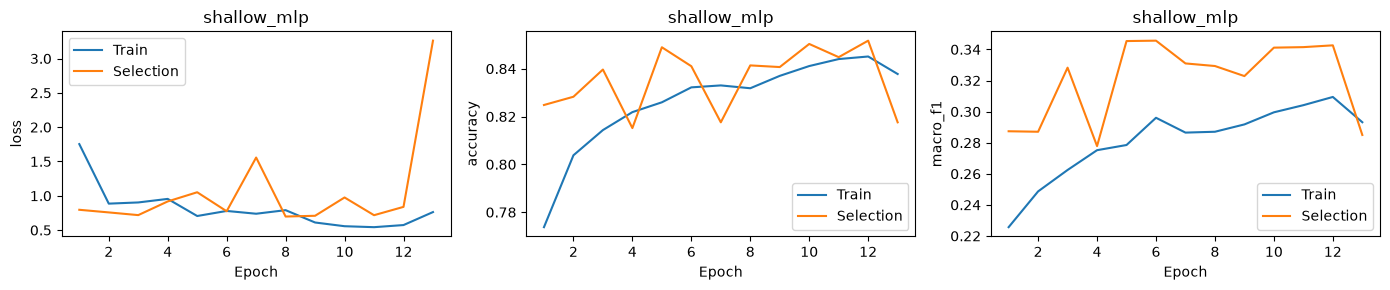

In [15]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in ['shallow_mlp']:
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('usage')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.1.5. Evaluation Analysis

**Gender.** The selected shallow mlp configuration, `shallow_mlp_lower_lr`, achieves **84.69% selection accuracy and 0.7118 macro-F1**, using 9,438,725 parameters. The original configuration scored 82.00% accuracy and 0.6405 macro-F1; tuning changes macro-F1 by +0.0713. The restored best epoch is 8 of 12; its recorded training-minus-selection accuracy difference is +0.31 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Men**, has 1612 examples and recall 89.89%. Weak-recall examples include **Unisex** (36.02% recall, n=161); **Girls** (58.82% recall, n=51); **Boys** (73.33% recall, n=75). Macro-F1 averages over the 5 classes present in selection, rather than assuming all output classes are represented. These predictions concern catalogue audience labels, not a person’s gender identity. Similar product designs can appear in several catalogue categories, and the smaller Boys, Girls and Unisex groups make overall accuracy insufficient.

**Occasion.** The selected shallow mlp configuration, `shallow_mlp_lower_lr`, achieves **87.38% selection accuracy and 0.4522 macro-F1**, using 9,439,753 parameters. The original configuration scored 84.10% accuracy and 0.3456 macro-F1; tuning changes macro-F1 by +0.1065. The restored best epoch is 10 of 14; its recorded training-minus-selection accuracy difference is -0.57 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Casual**, has 2237 examples and recall 94.95%. Weak-recall examples include **Smart Casual** (0.00% recall, n=4); **Travel** (0.00% recall, n=2); **Party** (0.00% recall, n=1). Macro-F1 averages over the 8 classes present in selection, rather than assuming all output classes are represented. Occasion accuracy is dominated by Casual products. Sparse labels such as Party, Smart Casual and Travel have very small selection support; literal NA is retained as a dataset label and is not treated as a missing value. High accuracy does not establish broad occasion recognition.

![Gender shallow_mlp learning curves](../figures/gender_shallow_mlp_lower_lr_learning_curves.png)

![Occasion shallow_mlp learning curves](../figures/usage_shallow_mlp_lower_lr_learning_curves.png)


### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [16]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['gender']['deeper_mlp'].summary()
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['usage']['deeper_mlp'].summary()

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,478,917 (36.16 MB)

 Trainable params: 9,478,917 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 9)              │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,479,177 (36.16 MB)

 Trainable params: 9,479,177 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [17]:
model = models['gender']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
model = models['usage']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])

#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [18]:
loaders['gender']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['gender']['deeper_mlp'].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['gender']['deeper_mlp'] = pd.DataFrame(fitted.history)
display(histories['gender']['deeper_mlp'].tail())
loaders['usage']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['usage']['deeper_mlp'].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['usage']['deeper_mlp'] = pd.DataFrame(fitted.history)
display(histories['usage']['deeper_mlp'].tail())

Epoch 1/30
423/423 - 13s - 30ms/step - accuracy: 0.6738 - loss: 1.2692 - macro_f1: 0.3031 - val_accuracy: 0.7593 - val_loss: 0.6631 - val_macro_f1: 0.3618
Epoch 2/30
423/423 - 11s - 27ms/step - accuracy: 0.7537 - loss: 0.6720 - macro_f1: 0.3522 - val_accuracy: 0.7555 - val_loss: 0.5880 - val_macro_f1: 0.3644
Epoch 3/30
423/423 - 11s - 27ms/step - accuracy: 0.7748 - loss: 0.6037 - macro_f1: 0.3663 - val_accuracy: 0.7631 - val_loss: 0.7427 - val_macro_f1: 0.3748
Epoch 4/30
423/423 - 11s - 27ms/step - accuracy: 0.7792 - loss: 0.6231 - macro_f1: 0.3877 - val_accuracy: 0.7917 - val_loss: 0.5363 - val_macro_f1: 0.3845
Epoch 5/30
423/423 - 11s - 27ms/step - accuracy: 0.7975 - loss: 0.5554 - macro_f1: 0.4425 - val_accuracy: 0.8062 - val_loss: 0.5251 - val_macro_f1: 0.5101
Epoch 6/30
423/423 - 11s - 27ms/step - accuracy: 0.8020 - loss: 0.5427 - macro_f1: 0.4726 - val_accuracy: 0.8052 - val_loss: 0.5208 - val_macro_f1: 0.4953
Epoch 7/30
423/423 - 12s - 28ms/step - accuracy: 0.8082 - loss: 0.5266

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.840450,0.436473,0.569027,0.841724,0.449299,0.633258
26,0.843000,0.433898,0.572320,0.840690,0.447873,0.581529
27,0.844368,0.429684,0.592270,0.832759,0.469649,0.546176
28,0.843777,0.432388,0.600675,0.835517,0.461902,0.640925
29,0.845662,0.434417,0.597543,0.843448,0.456207,0.634967


Epoch 1/30
423/423 - 12s - 30ms/step - accuracy: 0.7261 - loss: 1.2949 - macro_f1: 0.1795 - val_accuracy: 0.8110 - val_loss: 0.6401 - val_macro_f1: 0.2797
Epoch 2/30
423/423 - 12s - 28ms/step - accuracy: 0.7949 - loss: 0.7086 - macro_f1: 0.2266 - val_accuracy: 0.8255 - val_loss: 0.5570 - val_macro_f1: 0.2896
Epoch 3/30
423/423 - 12s - 28ms/step - accuracy: 0.8134 - loss: 0.6156 - macro_f1: 0.2486 - val_accuracy: 0.8297 - val_loss: 0.5835 - val_macro_f1: 0.3079
Epoch 4/30
423/423 - 12s - 28ms/step - accuracy: 0.8200 - loss: 0.5977 - macro_f1: 0.2716 - val_accuracy: 0.8183 - val_loss: 0.5287 - val_macro_f1: 0.2754
Epoch 5/30
423/423 - 12s - 28ms/step - accuracy: 0.8243 - loss: 0.5599 - macro_f1: 0.2662 - val_accuracy: 0.8366 - val_loss: 0.5073 - val_macro_f1: 0.3200
Epoch 6/30
423/423 - 12s - 27ms/step - accuracy: 0.8283 - loss: 0.5714 - macro_f1: 0.2717 - val_accuracy: 0.8407 - val_loss: 0.5112 - val_macro_f1: 0.3285
Epoch 7/30
423/423 - 11s - 27ms/step - accuracy: 0.8363 - loss: 0.5156

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
13,0.852274,0.452632,0.306859,0.849655,0.451430,0.332779
14,0.853567,0.457237,0.307736,0.852069,0.461230,0.346664
15,0.852643,0.448051,0.307418,0.856552,0.437164,0.344095
16,0.854603,0.438742,0.310191,0.855172,0.431788,0.345275
17,0.854787,0.435016,0.309214,0.861379,0.436904,0.358459


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender deeper_mlp


selection_accuracy    0.835517
selection_macro_f1    0.640925
dtype: float64

,precision,recall,f1-score,support
Boys,0.772727,0.680000,0.723404,75.000000
Girls,0.452381,0.372549,0.408602,51.000000
Men,0.818086,0.959677,0.883243,1612.000000
Unisex,0.972973,0.223602,0.363636,161.000000
Women,0.891204,0.769231,0.825737,1001.000000
accuracy,0.835517,0.835517,0.835517,0.835517
macro avg,0.781474,0.601012,0.640925,2900.000000
weighted avg,0.844318,0.835517,0.822066,2900.000000


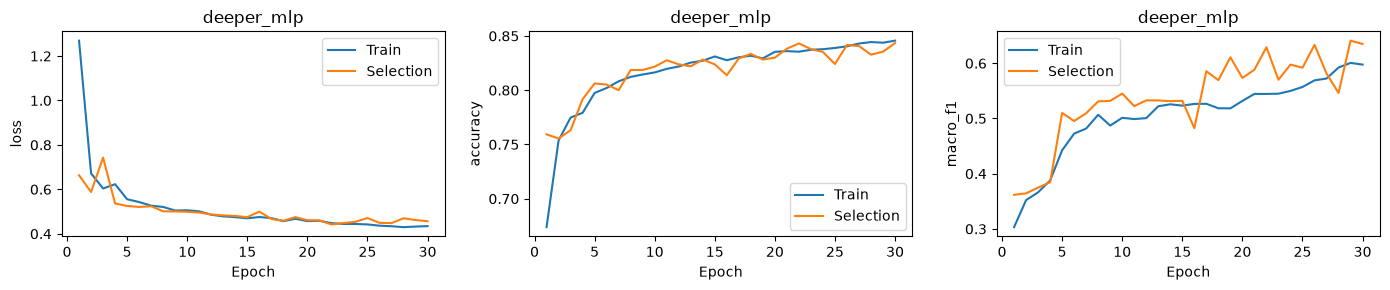

In [19]:
# Gender
loader = loaders['gender']['selection']
for method in ['deeper_mlp']:
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('gender')}_{method}_learning_curves.png", dpi=160)
    plt.show()

usage deeper_mlp


selection_accuracy    0.856207
selection_macro_f1    0.359960
dtype: float64

,precision,recall,f1-score,support
Casual,0.878838,0.946804,0.911556,2237.000000
Ethnic,0.651961,0.801205,0.718919,166.000000
Formal,0.861314,0.662921,0.749206,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.765101,0.371336,0.500000,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.856207,0.856207,0.856207,0.856207


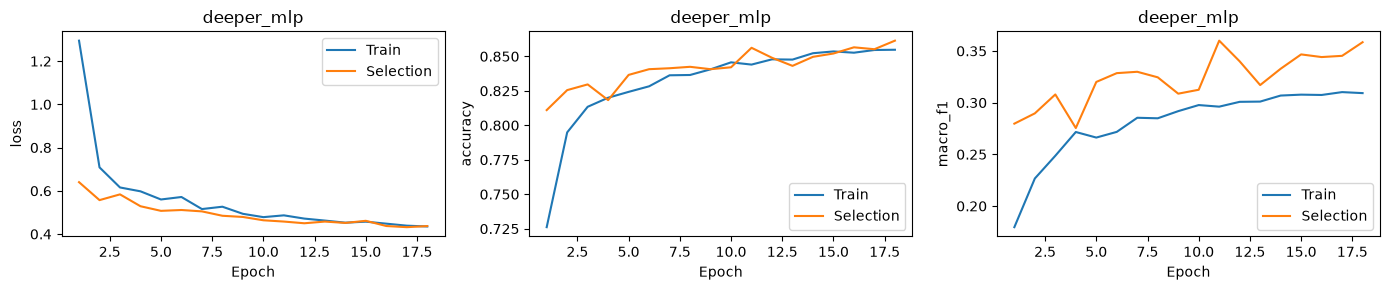

In [20]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in ['deeper_mlp']:
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('usage')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.2.5. Evaluation Analysis

**Gender.** The selected deeper mlp configuration, `deeper_mlp`, achieves **83.55% selection accuracy and 0.6409 macro-F1**, using 9,478,917 parameters. Compared with the selected shallow baseline, the macro-F1 difference is -0.0708, so extra dense depth must be judged by measured generalization rather than layer count. The restored best epoch is 29 of 30; its recorded training-minus-selection accuracy difference is +0.83 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Men**, has 1612 examples and recall 95.97%. Weak-recall examples include **Unisex** (22.36% recall, n=161); **Girls** (37.25% recall, n=51); **Boys** (68.00% recall, n=75). Macro-F1 averages over the 5 classes present in selection, rather than assuming all output classes are represented. These predictions concern catalogue audience labels, not a person’s gender identity. Similar product designs can appear in several catalogue categories, and the smaller Boys, Girls and Unisex groups make overall accuracy insufficient.

**Occasion.** The selected deeper mlp configuration, `deeper_mlp_lower_lr`, achieves **85.38% selection accuracy and 0.3623 macro-F1**, using 9,479,177 parameters. The original configuration scored 85.62% accuracy and 0.3600 macro-F1; tuning changes macro-F1 by +0.0024. Compared with the selected shallow baseline, the macro-F1 difference is -0.0898, so extra dense depth must be judged by measured generalization rather than layer count. The restored best epoch is 11 of 15; its recorded training-minus-selection accuracy difference is -0.40 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Casual**, has 2237 examples and recall 93.61%. Weak-recall examples include **NA** (0.00% recall, n=5); **Smart Casual** (0.00% recall, n=4); **Travel** (0.00% recall, n=2). Macro-F1 averages over the 8 classes present in selection, rather than assuming all output classes are represented. Occasion accuracy is dominated by Casual products. Sparse labels such as Party, Smart Casual and Travel have very small selection support; literal NA is retained as a dataset label and is not treated as a missing value. High accuracy does not establish broad occasion recognition.

![Gender deeper_mlp learning curves](../figures/gender_deeper_mlp_learning_curves.png)

![Occasion deeper_mlp learning curves](../figures/usage_deeper_mlp_lower_lr_learning_curves.png)


### 5.3. Convolutional Neural Network (CNN)


The CNN learns local patterns through convolutions and progressively reduces spatial resolution through pooling. Three-block and four-block variants test model capacity, while the scheduled three-block variant isolates the effect of learning-rate reduction. All three remain one CNN family in the main comparison table.


#### 5.3.1. Model Architecture

Convolutions learn local spatial patterns, unlike the flattened MLP inputs. Compare three blocks, the same architecture with a learning-rate schedule, and a four-block variant. Batch normalization stabilizes activations; pooling reduces spatial size. All variants end with a 2 ? 2 pooled grid and a dense head.


In [21]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
    models['gender'][method] = keras.Sequential(layers, name=method)
    models['gender'][method].summary()
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
    models['usage'][method] = keras.Sequential(layers, name=method)
    models['usage'][method].summary()

Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           645 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,453 (626.77 KB)

 Trainable params: 160,005 (625.02 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_four_blocks_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_9 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 655,049 (2.50 MB)

 Trainable params: 654,089 (2.50 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.


In [22]:
for method in CNN_CONFIGS:
    models['gender'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
for method in CNN_CONFIGS:
    models['usage'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])

#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.


In [23]:
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['gender']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    fitted = models['gender'][method].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
    histories['gender'][method] = pd.DataFrame(fitted.history)
    display(histories['gender'][method].tail())
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['usage']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    fitted = models['usage'][method].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
    histories['usage'][method] = pd.DataFrame(fitted.history)
    display(histories['usage'][method].tail())

Epoch 1/30


2026-09-11 07:48:10.260384: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


423/423 - 28s - 65ms/step - accuracy: 0.7202 - loss: 0.7141 - macro_f1: 0.3171 - val_accuracy: 0.6541 - val_loss: 0.8230 - val_macro_f1: 0.3103
Epoch 2/30
423/423 - 25s - 58ms/step - accuracy: 0.7771 - loss: 0.5712 - macro_f1: 0.4073 - val_accuracy: 0.7590 - val_loss: 0.6185 - val_macro_f1: 0.4543
Epoch 3/30
423/423 - 25s - 58ms/step - accuracy: 0.8056 - loss: 0.5169 - macro_f1: 0.4859 - val_accuracy: 0.7655 - val_loss: 0.6077 - val_macro_f1: 0.4894
Epoch 4/30
423/423 - 25s - 58ms/step - accuracy: 0.8178 - loss: 0.4876 - macro_f1: 0.5417 - val_accuracy: 0.7976 - val_loss: 0.5327 - val_macro_f1: 0.4528
Epoch 5/30
423/423 - 25s - 59ms/step - accuracy: 0.8268 - loss: 0.4658 - macro_f1: 0.5720 - val_accuracy: 0.8331 - val_loss: 0.4657 - val_macro_f1: 0.6100
Epoch 6/30
423/423 - 25s - 58ms/step - accuracy: 0.8370 - loss: 0.4412 - macro_f1: 0.6000 - val_accuracy: 0.8041 - val_loss: 0.5329 - val_macro_f1: 0.4711
Epoch 7/30
423/423 - 25s - 58ms/step - accuracy: 0.8440 - loss: 0.4292 - macro_f1

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
17,0.877749,0.335263,0.708417,0.831379,0.473207,0.623781
18,0.879709,0.325528,0.710504,0.846897,0.437400,0.577110
19,0.883258,0.322172,0.732611,0.791379,0.575464,0.640309
20,0.884884,0.318736,0.726486,0.780690,0.715427,0.464474
21,0.888840,0.307416,0.739302,0.845862,0.417123,0.679548


Epoch 1/30
423/423 - 25s - 60ms/step - accuracy: 0.7202 - loss: 0.7141 - macro_f1: 0.3171 - val_accuracy: 0.6541 - val_loss: 0.8230 - val_macro_f1: 0.3103 - learning_rate: 0.0010
Epoch 2/30
423/423 - 24s - 57ms/step - accuracy: 0.7771 - loss: 0.5712 - macro_f1: 0.4073 - val_accuracy: 0.7590 - val_loss: 0.6185 - val_macro_f1: 0.4543 - learning_rate: 0.0010
Epoch 3/30
423/423 - 24s - 56ms/step - accuracy: 0.8056 - loss: 0.5169 - macro_f1: 0.4859 - val_accuracy: 0.7655 - val_loss: 0.6077 - val_macro_f1: 0.4894 - learning_rate: 0.0010
Epoch 4/30
423/423 - 24s - 57ms/step - accuracy: 0.8178 - loss: 0.4876 - macro_f1: 0.5417 - val_accuracy: 0.7976 - val_loss: 0.5327 - val_macro_f1: 0.4528 - learning_rate: 0.0010
Epoch 5/30
423/423 - 24s - 56ms/step - accuracy: 0.8268 - loss: 0.4658 - macro_f1: 0.5720 - val_accuracy: 0.8331 - val_loss: 0.4657 - val_macro_f1: 0.6100 - learning_rate: 0.0010
Epoch 6/30
423/423 - 24s - 56ms/step - accuracy: 0.8370 - loss: 0.4412 - macro_f1: 0.6000 - val_accuracy:

...

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.896155,0.291574,0.393448,0.885172,0.359621,0.388391
26,0.898152,0.283409,0.383933,0.864828,0.398201,0.374353
27,0.900148,0.279863,0.391787,0.882069,0.358027,0.390881
28,0.901442,0.274346,0.410999,0.881379,0.389191,0.392135
29,0.903290,0.269877,0.409555,0.881034,0.377012,0.387582


Epoch 1/30
423/423 - 25s - 60ms/step - accuracy: 0.7882 - loss: 0.6422 - macro_f1: 0.1859 - val_accuracy: 0.7728 - val_loss: 0.6281 - val_macro_f1: 0.1224 - learning_rate: 0.0010
Epoch 2/30
423/423 - 24s - 57ms/step - accuracy: 0.8174 - loss: 0.5263 - macro_f1: 0.2498 - val_accuracy: 0.8255 - val_loss: 0.4827 - val_macro_f1: 0.3021 - learning_rate: 0.0010
Epoch 3/30
423/423 - 24s - 56ms/step - accuracy: 0.8341 - loss: 0.4817 - macro_f1: 0.2771 - val_accuracy: 0.8217 - val_loss: 0.4900 - val_macro_f1: 0.3066 - learning_rate: 0.0010
Epoch 4/30
423/423 - 24s - 56ms/step - accuracy: 0.8406 - loss: 0.4551 - macro_f1: 0.2901 - val_accuracy: 0.8131 - val_loss: 0.5516 - val_macro_f1: 0.3355 - learning_rate: 0.0010
Epoch 5/30
423/423 - 24s - 57ms/step - accuracy: 0.8451 - loss: 0.4376 - macro_f1: 0.2987 - val_accuracy: 0.7672 - val_loss: 0.6055 - val_macro_f1: 0.3312 - learning_rate: 0.0010
Epoch 6/30
423/423 - 24s - 57ms/step - accuracy: 0.8515 - loss: 0.4258 - macro_f1: 0.3072 - val_accuracy:

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
21,0.892717,0.308131,0.355585,0.883103,0.349640,0.393181,0.000016
22,0.892569,0.305043,0.355619,0.880000,0.352281,0.387778,0.000016
23,0.892791,0.305904,0.355783,0.883103,0.349147,0.393275,0.000008
24,0.893494,0.303753,0.369063,0.882414,0.348180,0.392550,0.000008
25,0.893050,0.302417,0.368464,0.884138,0.348961,0.393125,0.000004


Epoch 1/30
423/423 - 29s - 69ms/step - accuracy: 0.8059 - loss: 0.5992 - macro_f1: 0.2303 - val_accuracy: 0.8166 - val_loss: 0.5304 - val_macro_f1: 0.2508 - learning_rate: 0.0010
Epoch 2/30
423/423 - 28s - 65ms/step - accuracy: 0.8379 - loss: 0.4696 - macro_f1: 0.2872 - val_accuracy: 0.8334 - val_loss: 0.4864 - val_macro_f1: 0.3103 - learning_rate: 0.0010
Epoch 3/30
423/423 - 28s - 66ms/step - accuracy: 0.8525 - loss: 0.4248 - macro_f1: 0.3117 - val_accuracy: 0.8248 - val_loss: 0.6030 - val_macro_f1: 0.2757 - learning_rate: 0.0010
Epoch 4/30
423/423 - 28s - 65ms/step - accuracy: 0.8613 - loss: 0.4027 - macro_f1: 0.3215 - val_accuracy: 0.8507 - val_loss: 0.4332 - val_macro_f1: 0.3719 - learning_rate: 0.0010
Epoch 5/30
423/423 - 28s - 65ms/step - accuracy: 0.8674 - loss: 0.3822 - macro_f1: 0.3297 - val_accuracy: 0.8286 - val_loss: 0.4841 - val_macro_f1: 0.3579 - learning_rate: 0.0010
Epoch 6/30
423/423 - 28s - 66ms/step - accuracy: 0.8753 - loss: 0.3619 - macro_f1: 0.3386 - val_accuracy:

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.951978,0.139134,0.431853,0.904828,0.329500,0.412681,0.000063
26,0.953161,0.134034,0.444447,0.904828,0.300100,0.418307,0.000063
27,0.954935,0.129070,0.445776,0.902414,0.305439,0.417561,0.000031
28,0.955601,0.125650,0.441699,0.906552,0.314468,0.417004,0.000031
29,0.958152,0.121446,0.465386,0.904828,0.306812,0.417529,0.000016


#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


gender cnn_ordinary


selection_accuracy    0.863448
selection_macro_f1    0.699898
dtype: float64

,precision,recall,f1-score,support
Boys,0.721519,0.760000,0.740260,75.000000
Girls,0.656250,0.411765,0.506024,51.000000
Men,0.869441,0.946030,0.906120,1612.000000
Unisex,0.780822,0.354037,0.487179,161.000000
Women,0.877339,0.843157,0.859908,1001.000000
accuracy,0.863448,0.863448,0.863448,0.863448
macro avg,0.781074,0.662998,0.699898,2900.000000
weighted avg,0.859673,0.863448,0.855585,2900.000000


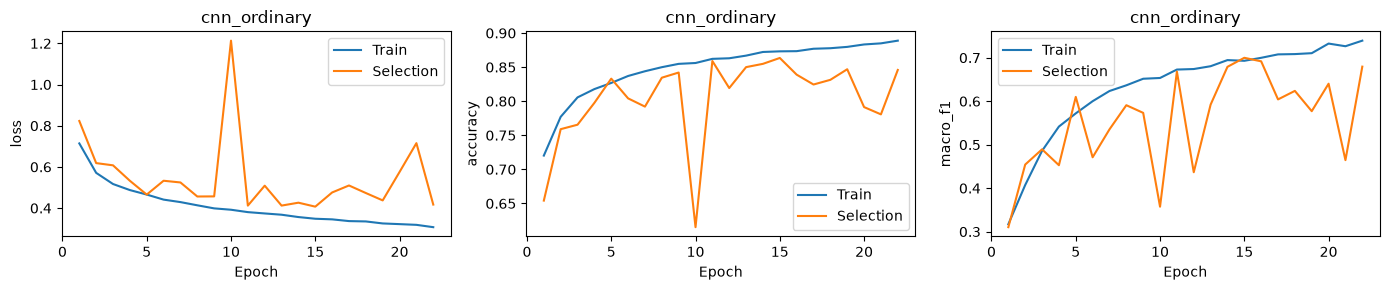

gender cnn_scheduled


selection_accuracy    0.878966
selection_macro_f1    0.733420
dtype: float64

,precision,recall,f1-score,support
Boys,0.702381,0.786667,0.742138,75.000000
Girls,0.690476,0.568627,0.623656,51.000000
Men,0.888437,0.948511,0.917492,1612.000000
Unisex,0.734940,0.378882,0.500000,161.000000
Women,0.897938,0.870130,0.883815,1001.000000
accuracy,0.878966,0.878966,0.878966,0.878966
macro avg,0.782834,0.710563,0.733420,2900.000000
weighted avg,0.874902,0.878966,0.872987,2900.000000


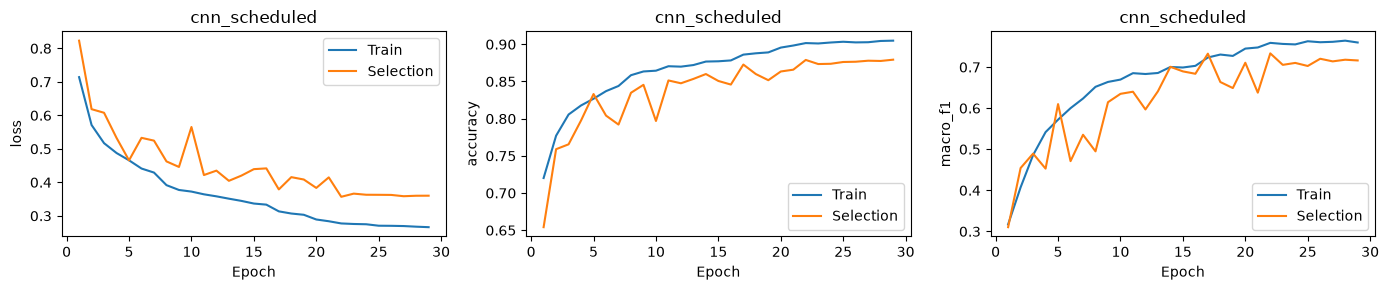

gender cnn_four_blocks_scheduled


selection_accuracy    0.899310
selection_macro_f1    0.790123
dtype: float64

,precision,recall,f1-score,support
Boys,0.791667,0.760000,0.775510,75.00000
Girls,0.650794,0.803922,0.719298,51.00000
Men,0.914868,0.946650,0.930488,1612.00000
Unisex,0.735043,0.534161,0.618705,161.00000
Women,0.916327,0.897103,0.906613,1001.00000
accuracy,0.899310,0.899310,0.899310,0.89931
macro avg,0.801740,0.788367,0.790123,2900.00000
weighted avg,0.897558,0.899310,0.897215,2900.00000


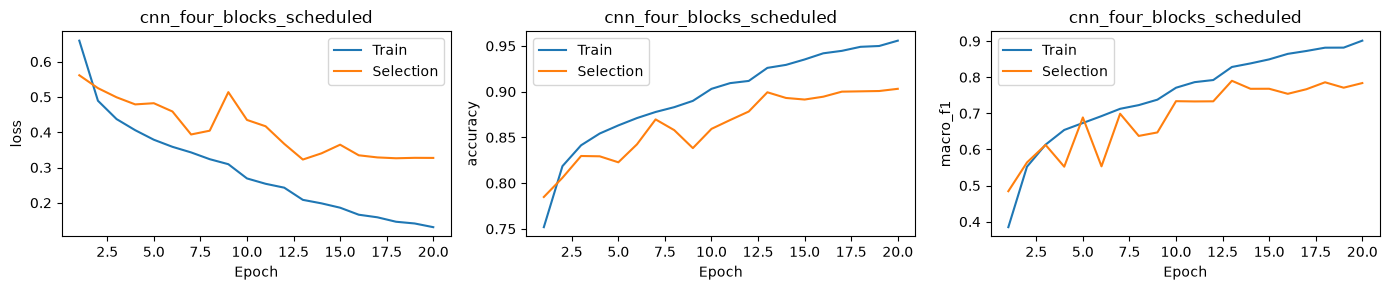

In [24]:
# Gender
loader = loaders['gender']['selection']
for method in list(CNN_CONFIGS):
    model = models['gender'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('gender', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    history = histories['gender'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('gender')}_{method}_learning_curves.png", dpi=160)
    plt.show()

usage cnn_ordinary


selection_accuracy    0.876207
selection_macro_f1    0.396290
dtype: float64

,precision,recall,f1-score,support
Casual,0.921700,0.920876,0.921288,2237.000000
Ethnic,0.776650,0.921687,0.842975,166.000000
Formal,0.783133,0.730337,0.755814,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.655629,0.644951,0.650246,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.876207,0.876207,0.876207,0.876207


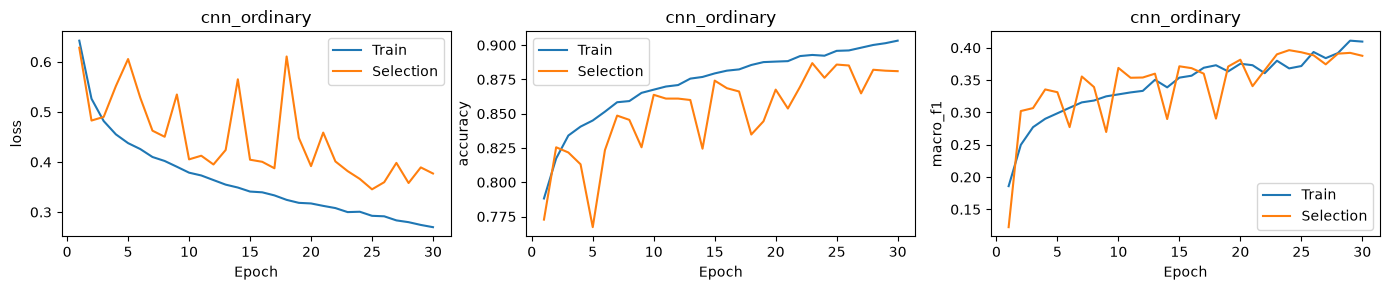

usage cnn_scheduled


selection_accuracy    0.880345
selection_macro_f1    0.394620
dtype: float64

,precision,recall,f1-score,support
Casual,0.910784,0.940098,0.925209,2237.000000
Ethnic,0.797814,0.879518,0.836676,166.000000
Formal,0.811321,0.724719,0.765579,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.702811,0.570033,0.629496,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.880345,0.880345,0.880345,0.880345


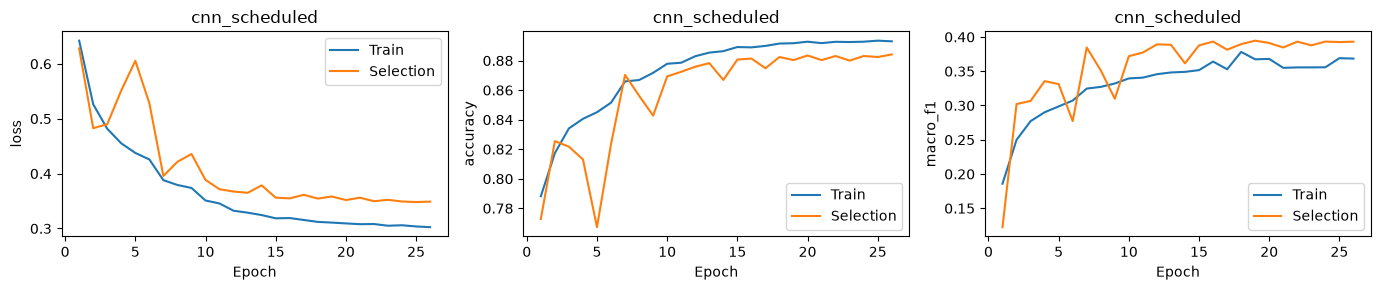

usage cnn_four_blocks_scheduled


selection_accuracy    0.904828
selection_macro_f1    0.418654
dtype: float64

,precision,recall,f1-score,support
Casual,0.928540,0.952615,0.940424,2237.000000
Ethnic,0.877193,0.903614,0.890208,166.000000
Formal,0.850932,0.769663,0.808260,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.754579,0.671010,0.710345,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.904828,0.904828,0.904828,0.904828


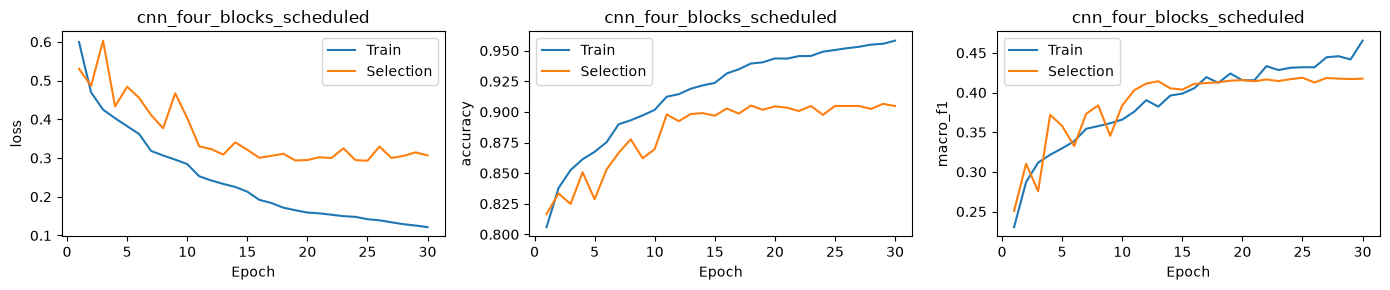

In [25]:
# Occasion (usage)
loader = loaders['usage']['selection']
for method in list(CNN_CONFIGS):
    model = models['usage'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('usage', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    history = histories['usage'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('usage')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.3.5. Evaluation Analysis

**Gender.** The selected cnn configuration, `cnn_four_blocks_scheduled`, achieves **89.93% selection accuracy and 0.7901 macro-F1**, using 654,021 parameters. The macro-F1 gain over the selected deeper MLP is +0.1492. The CNN learns spatial patterns with far fewer parameters than the flattened MLPs. The restored best epoch is 13 of 20; its recorded training-minus-selection accuracy difference is +2.67 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Men**, has 1612 examples and recall 94.67%. Weak-recall examples include **Unisex** (53.42% recall, n=161); **Boys** (76.00% recall, n=75); **Girls** (80.39% recall, n=51). Macro-F1 averages over the 5 classes present in selection, rather than assuming all output classes are represented. These predictions concern catalogue audience labels, not a person’s gender identity. Similar product designs can appear in several catalogue categories, and the smaller Boys, Girls and Unisex groups make overall accuracy insufficient. There are 0 selection-supported classes with zero recall.

**Occasion.** The selected cnn configuration, `cnn_continue_weighted`, achieves **89.55% selection accuracy and 0.4497 macro-F1**, using 655,049 parameters. The original configuration scored 90.48% accuracy and 0.4187 macro-F1; tuning changes macro-F1 by +0.0311. The macro-F1 gain over the selected deeper MLP is +0.0874. The CNN learns spatial patterns with far fewer parameters than the flattened MLPs. The restored best continuation epoch is 6 of 8; its recorded training-minus-selection accuracy difference is +5.71 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Casual**, has 2237 examples and recall 93.16%. Weak-recall examples include **Smart Casual** (0.00% recall, n=4); **Travel** (0.00% recall, n=2); **Party** (0.00% recall, n=1). Macro-F1 averages over the 8 classes present in selection, rather than assuming all output classes are represented. Occasion accuracy is dominated by Casual products. Sparse labels such as Party, Smart Casual and Travel have very small selection support; literal NA is retained as a dataset label and is not treated as a missing value. High accuracy does not establish broad occasion recognition. There are 3 selection-supported classes with zero recall. Among classes with at least ten selection examples, weak recall includes Sports (70.03%, n=307); Formal (80.90%, n=178); Ethnic (92.17%, n=166).

![Gender cnn learning curves](../figures/gender_cnn_four_blocks_scheduled_learning_curves.png)

![Occasion cnn learning curves](../figures/usage_cnn_continue_weighted_learning_curves.png)


#### 5.3.6. Target-specific parameter tuning

The completed first run motivates lower learning rates for the unstable MLPs and a short CNN continuation with and without class weighting. These are additional candidates, not assumed improvements. Only training counts determine weights; selection macro-F1 chooses the winner. Calibration, policy and internal-test images are excluded from fitting.

Both CNN candidates start from identical selected CNN weights. Their shared learning rate, dropout, seed and epoch budget isolate the effect of class weights. Each MLP keeps its original architecture and uses a lower learning rate for up to 20 epochs. CNN continuation uses up to 8 additional epochs; its history records additional epochs only.

**Execution record:** This tuning round reused the four exported CNNs after the previous kernel shut down. Original MLP/CNN fitting cells were not rerun. Their measured histories and experiment rows were loaded for comparison; only the added candidates were fitted. For a future fresh Run All, `RESUME_SAVED_RESULTS=False` prevents mixing previous experiment rows into the new run. To resume intentionally, enable it only with matching data, splits, label order and preprocessing, and load the corresponding history CSVs before comparison.


**gender: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 3 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [11]:
PARAMETER_CONFIGS_gender = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=1e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=1e-05, epochs=8, weighted=True),
}
counts = np.bincount(loaders['gender']['train'].targets, minlength=len(labels_by_target['gender']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 3)
class_weights_gender = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['gender']:
    tuning_source_gender = models['gender']['cnn_four_blocks_scheduled']
else:
    tuning_source_gender = keras.models.load_model(OUTPUT / f"{stem_for('gender')}_model.keras", compile=False)
    saved_metadata = tuning_source_gender.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'gender' and saved_metadata['labels'] == labels_by_target['gender']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['gender'][saved_metadata['model_type']] = tuning_source_gender
for method, config in PARAMETER_CONFIGS_gender.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_gender)
        candidate.set_weights(tuning_source_gender.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = [256] if config['family'] == 'shallow_mlp' else [256, 128, 64]
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['gender']))])
    models['gender'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_gender).T.to_csv(RESULTS / f"{stem_for('gender')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_gender).T)


I0000 00:00:1789098910.422371  227338 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


,family,learning_rate,epochs,weighted
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False
cnn_continue,cnn,0.00001,8,False
cnn_continue_weighted,cnn,0.00001,8,True


**gender: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models/model_training_apis/)).


In [12]:
for method, config in PARAMETER_CONFIGS_gender.items():
    keras.utils.set_random_seed(SEED)
    loaders['gender']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('gender', method, flush=True)
    fitted = models['gender'][method].fit(loaders['gender']['train'], validation_data=loaders['gender']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_gender if config['weighted'] else None, shuffle=False, verbose=2)
    histories['gender'][method] = pd.DataFrame(fitted.history)
    histories['gender'][method].to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
    display(histories['gender'][method].tail())


gender shallow_mlp_lower_lr


Epoch 1/20


423/423 - 12s - 29ms/step - accuracy: 0.7737 - loss: 0.6562 - macro_f1: 0.5008 - val_accuracy: 0.8121 - val_loss: 0.5504 - val_macro_f1: 0.5726


Epoch 2/20


423/423 - 11s - 26ms/step - accuracy: 0.8170 - loss: 0.5379 - macro_f1: 0.5889 - val_accuracy: 0.8210 - val_loss: 0.4906 - val_macro_f1: 0.5999


...

Epoch 7/8


423/423 - 26s - 62ms/step - accuracy: 0.9358 - loss: 0.2274 - macro_f1: 0.8629 - val_accuracy: 0.8962 - val_loss: 0.3345 - val_macro_f1: 0.7813


Epoch 8/8


423/423 - 26s - 61ms/step - accuracy: 0.9366 - loss: 0.2246 - macro_f1: 0.8652 - val_accuracy: 0.8934 - val_loss: 0.3353 - val_macro_f1: 0.7795


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
3,0.932868,0.240247,0.850431,0.894483,0.336598,0.780303
4,0.933718,0.233878,0.851239,0.893103,0.337689,0.778586
5,0.933903,0.232437,0.853986,0.892414,0.334721,0.774600
6,0.935825,0.227444,0.862920,0.896207,0.334451,0.781260
7,0.936564,0.224594,0.865228,0.893448,0.335300,0.779521


**gender: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [13]:
loader = loaders['gender']['selection']
for method in PARAMETER_CONFIGS_gender:
    probabilities = np.vstack([tf.nn.softmax(models['gender'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['gender'])), target_names=labels_by_target['gender'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.846897
macro_f1                0.711753
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.818276
macro_f1                0.61767
dtype: object

method      cnn_continue
accuracy        0.901724
macro_f1          0.7808
dtype: object

method      cnn_continue_weighted
accuracy                 0.896207
macro_f1                  0.78126
dtype: object

**usage: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 6 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [14]:
PARAMETER_CONFIGS_usage = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=True),
}
counts = np.bincount(loaders['usage']['train'].targets, minlength=len(labels_by_target['usage']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 6)
class_weights_usage = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['usage']:
    tuning_source_usage = models['usage']['cnn_four_blocks_scheduled']
else:
    tuning_source_usage = keras.models.load_model(OUTPUT / f"{stem_for('usage')}_model.keras", compile=False)
    saved_metadata = tuning_source_usage.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'usage' and saved_metadata['labels'] == labels_by_target['usage']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['usage'][saved_metadata['model_type']] = tuning_source_usage
for method, config in PARAMETER_CONFIGS_usage.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_usage)
        candidate.set_weights(tuning_source_usage.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = [256] if config['family'] == 'shallow_mlp' else [256, 128, 64]
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['usage']))])
    models['usage'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_usage).T.to_csv(RESULTS / f"{stem_for('usage')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_usage).T)


,family,learning_rate,epochs,weighted
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False
cnn_continue,cnn,0.00003,8,False
cnn_continue_weighted,cnn,0.00003,8,True


**usage: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models/model_training_apis/)).


In [15]:
for method, config in PARAMETER_CONFIGS_usage.items():
    keras.utils.set_random_seed(SEED)
    loaders['usage']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('usage', method, flush=True)
    fitted = models['usage'][method].fit(loaders['usage']['train'], validation_data=loaders['usage']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_usage if config['weighted'] else None, shuffle=False, verbose=2)
    histories['usage'][method] = pd.DataFrame(fitted.history)
    histories['usage'][method].to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
    display(histories['usage'][method].tail())


usage shallow_mlp_lower_lr


Epoch 1/20


423/423 - 9s - 22ms/step - accuracy: 0.8059 - loss: 0.6590 - macro_f1: 0.2581 - val_accuracy: 0.8352 - val_loss: 0.5188 - val_macro_f1: 0.3129


Epoch 2/20


423/423 - 9s - 21ms/step - accuracy: 0.8315 - loss: 0.5274 - macro_f1: 0.2896 - val_accuracy: 0.8531 - val_loss: 0.5089 - val_macro_f1: 0.3496


...

Epoch 7/8


423/423 - 26s - 62ms/step - accuracy: 0.9507 - loss: 0.1781 - macro_f1: 0.5786 - val_accuracy: 0.8921 - val_loss: 0.3258 - val_macro_f1: 0.4492


Epoch 8/8


423/423 - 26s - 61ms/step - accuracy: 0.9532 - loss: 0.1741 - macro_f1: 0.5768 - val_accuracy: 0.8928 - val_loss: 0.3211 - val_macro_f1: 0.4492


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
3,0.951091,0.188827,0.538219,0.881034,0.342549,0.443080
4,0.950462,0.186172,0.548790,0.881724,0.340006,0.446324
5,0.952643,0.180269,0.543190,0.895517,0.313832,0.449732
6,0.950721,0.178147,0.578611,0.892069,0.325848,0.449247
7,0.953161,0.174128,0.576821,0.892759,0.321103,0.449216


**usage: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [16]:
loader = loaders['usage']['selection']
for method in PARAMETER_CONFIGS_usage:
    probabilities = np.vstack([tf.nn.softmax(models['usage'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['usage'])), target_names=labels_by_target['usage'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.873793
macro_f1                0.452185
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.853793
macro_f1               0.362344
dtype: object

method      cnn_continue
accuracy        0.905517
macro_f1         0.41838
dtype: object

method      cnn_continue_weighted
accuracy                 0.895517
macro_f1                 0.449732
dtype: object

### 5.4. Model Comparison

Choose the best configuration within each of the three families using selection macro-F1, then accuracy, then fewer parameters. Original runs and the additional parameter experiments are compared on the same selection partition. The three-row table reports family winners; the experiments CSV retains candidate-level evidence.


In [17]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')

In [18]:
# Gender
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['gender']['selection']
for method, model in models['gender'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['gender'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('gender')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('gender')}_experiments.csv")
tuning['gender'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['gender'][f'{metric}_change_vs_ordinary'] = tuning['gender'][f'validation_{metric}'] - tuning['gender'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['gender']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['gender'] = ranked(table).index[0]
table['selected'] = table.index == winners['gender']
comparisons['gender'] = table
table.to_csv(RESULTS / f"{stem_for('gender')}_comparison.csv")
tuning['gender'].to_csv(RESULTS / f"{stem_for('gender')}_cnn_tuning.csv")
display(table)
display(tuning['gender'])
assert winners['gender'] in models['gender'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.846897,0.711753,0.020750,9438725,12,shallow_mlp,False
deeper_mlp,0.835517,0.640925,0.014398,9478917,30,deeper_mlp,False
cnn_four_blocks_scheduled,0.899310,0.790123,0.016783,654021,20,cnn,True


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.863448,0.699898,0.027388,160453,22,0.000000,0.000000
cnn_scheduled,0.878966,0.733420,0.012934,160453,29,0.015517,0.033522
cnn_four_blocks_scheduled,0.899310,0.790123,0.016783,654021,20,0.035862,0.090224
cnn_continue,0.901724,0.780800,0.020903,654021,5,0.038276,0.080902
cnn_continue_weighted,0.896207,0.781260,0.016520,654021,8,0.032759,0.081362


In [19]:
# Occasion (usage)
rows = []
loader = loaders['usage']['selection']
for method, model in models['usage'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['usage'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('usage')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('usage')}_experiments.csv")
tuning['usage'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['usage'][f'{metric}_change_vs_ordinary'] = tuning['usage'][f'validation_{metric}'] - tuning['usage'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['usage']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['usage'] = ranked(table).index[0]
table['selected'] = table.index == winners['usage']
comparisons['usage'] = table
table.to_csv(RESULTS / f"{stem_for('usage')}_comparison.csv")
tuning['usage'].to_csv(RESULTS / f"{stem_for('usage')}_cnn_tuning.csv")
display(table)
display(tuning['usage'])
assert winners['usage'] in models['usage'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.873793,0.452185,0.023828,9439753,14,shallow_mlp,True
deeper_mlp_lower_lr,0.853793,0.362344,0.034479,9479177,15,deeper_mlp,False
cnn_continue_weighted,0.895517,0.449732,0.028263,655049,8,cnn,False


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.876207,0.396290,0.021518,160969,30,0.000000,0.000000
cnn_scheduled,0.880345,0.394620,0.015619,160969,26,0.004138,-0.001670
cnn_four_blocks_scheduled,0.904828,0.418654,0.028082,655049,30,0.028621,0.022364
cnn_continue,0.905517,0.418380,0.038527,655049,5,0.029310,0.022090
cnn_continue_weighted,0.895517,0.449732,0.028263,655049,8,0.019310,0.053441


### 5.5. Learning Curves

Inspect the restored best epoch and later trajectory rather than the final epoch alone. Training enables augmentation and dropout; selection uses inference mode, so a negative training-minus-selection accuracy gap is possible.

The class-weighted CNN uses weighted training loss but unweighted validation loss. Their raw loss gap does not directly measure overfitting. Accuracy and supported-class macro-F1 remain unweighted and are comparable across candidates, subject to the training/inference-mode difference. CNN continuation plots count additional epochs from the shared starting checkpoint.


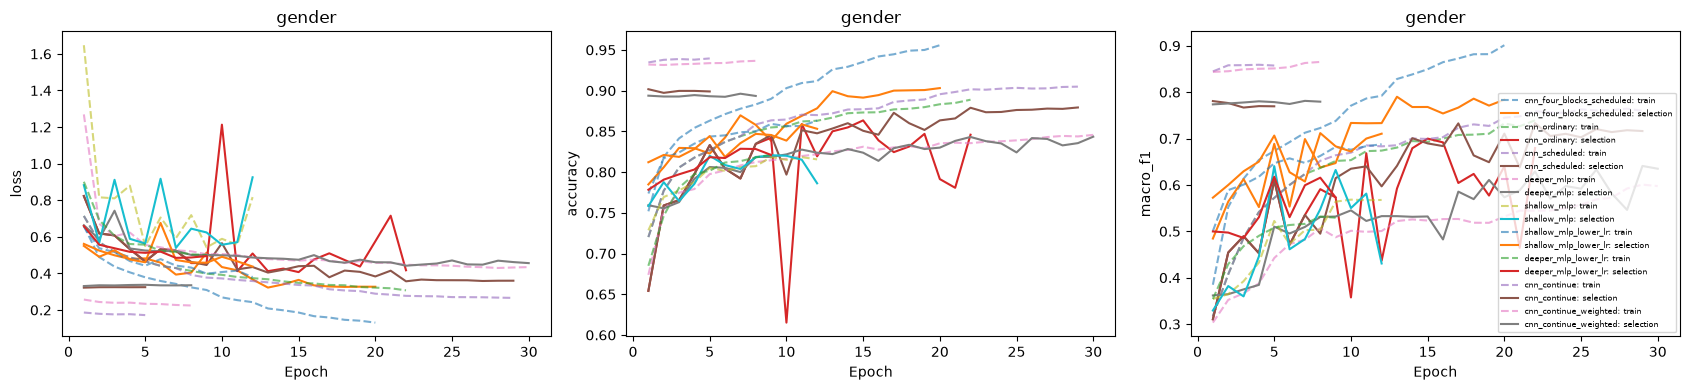

In [20]:
# Gender
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['gender'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='gender')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('gender')}_learning_curves.png", dpi=160)

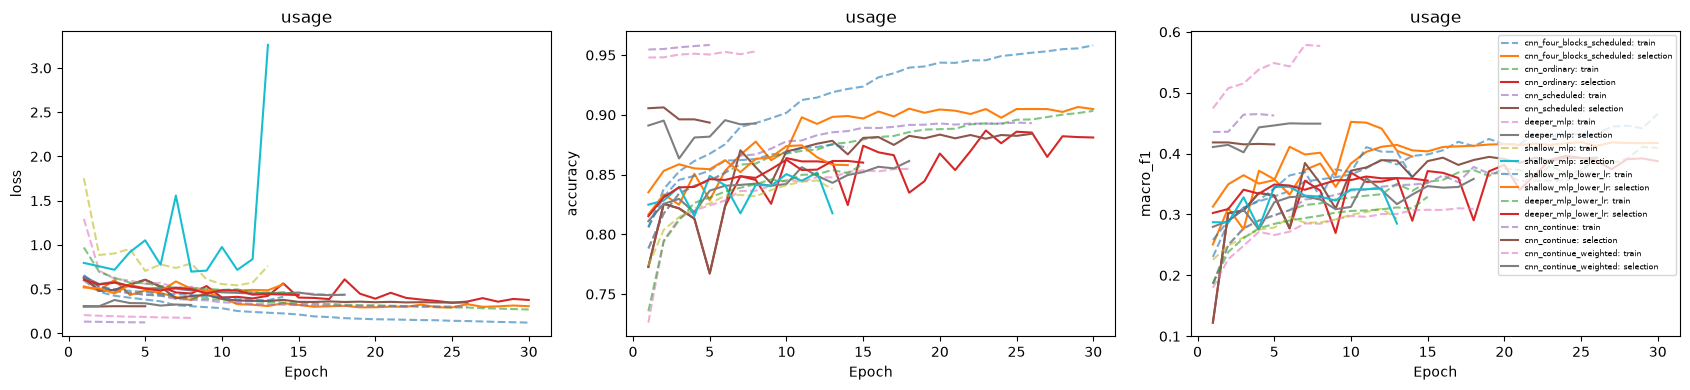

In [21]:
# Occasion (usage)
plt.show()
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['usage'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='usage')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('usage')}_learning_curves.png", dpi=160)
plt.show()

### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.


#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.


In [22]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]

#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.


In [23]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if values.ndim < 1 or values.shape[-1] == 0 or not np.isfinite(values).all() or (values < 0).any():
        raise ValueError('Probabilities must be finite, nonnegative vectors')
    mass = values.sum(axis=-1, keepdims=True)
    if (mass <= 0).any():
        raise ValueError('Probability vectors must have positive mass')
    # Softmax is computed in float32; renormalize after conversion to float64.
    values = values / mass
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)

#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.


In [24]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result

#### 5.6.4. Evaluate a partition

Compute accuracy, supported-class macro-F1, ECE, NLL and Brier score. Record sampled batch/single-image differences as a diagnostic; large differences or changed predictions warn, while invalid probabilities raise an error.


In [25]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}

#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.


In [26]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint

In [27]:
method = winners['gender']
checkpoints['gender'] = dict(target='gender', labels=labels_by_target['gender'], model=models['gender'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['gender'].loc[method].to_dict())
checkpoints['gender'] = calibrate(checkpoints['gender'], frames['gender']['calibration'], frames['gender']['policy'], DEVICE)
method = winners['usage']
checkpoints['usage'] = dict(target='usage', labels=labels_by_target['usage'], model=models['usage'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['usage'].loc[method].to_dict())
checkpoints['usage'] = calibrate(checkpoints['usage'], frames['usage']['calibration'], frames['usage']['policy'], DEVICE)

#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.


In [28]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['gender'], metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('test')], device=DEVICE)
test_results['gender'] = result
checkpoints['gender']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='gender'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('gender')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('gender')}_test_metrics.csv")
result = evaluate_saved_checkpoint(checkpoints['usage'], metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('test')], device=DEVICE)
test_results['usage'] = result
checkpoints['usage']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='usage'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('usage')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('usage')}_test_metrics.csv")

accuracy    0.889122
macro_f1    0.739821
ece         0.021677
nll         0.307347
brier       0.163259
Name: gender, dtype: float64

,precision,recall,f1-score,support
Boys,0.685950,0.638462,0.661355,130.000000
Girls,0.615385,0.648649,0.631579,111.000000
Men,0.904573,0.943702,0.923724,3144.000000
Unisex,0.674107,0.508418,0.579655,297.000000
Women,0.916498,0.889489,0.902792,2036.000000
accuracy,0.889122,0.889122,0.889122,0.889122
macro avg,0.759303,0.725744,0.739821,5718.000000
weighted avg,0.886264,0.889122,0.886763,5718.000000


accuracy    0.856943
macro_f1    0.374519
ece         0.023051
nll         0.460779
brier       0.216802
Name: usage, dtype: float64

,precision,recall,f1-score,support
Casual,0.882842,0.937340,0.909275,4309.000000
Ethnic,0.850136,0.751807,0.797954,415.000000
Formal,0.726073,0.656716,0.689655,335.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,23.000000
Party,0.000000,0.000000,0.000000,2.000000
Smart Casual,0.000000,0.000000,0.000000,7.000000
Sports,0.695560,0.526400,0.599271,625.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.856943,0.856943,0.856943,0.856943


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.


In [29]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )

In [30]:
result = test_results['gender']
display(calibration_table(result['truth'], result['probabilities']))
result = test_results['usage']
display(calibration_table(result['truth'], result['probabilities']))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",0.279714,0.666667,3
"(0.3, 0.4]",0.356292,0.294118,34
"(0.4, 0.5]",0.459686,0.445255,137
"(0.5, 0.6]",0.551674,0.549242,264
"(0.6, 0.7]",0.652374,0.628788,264
"(0.7, 0.8]",0.750402,0.672535,284
"(0.8, 0.9]",0.856828,0.774067,509


,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",NaN,NaN,0
"(0.2, 0.3]",NaN,NaN,0
"(0.3, 0.4]",0.368739,0.500000,6
"(0.4, 0.5]",0.475734,0.525253,99
"(0.5, 0.6]",0.548353,0.566116,484
"(0.6, 0.7]",0.649214,0.666667,453
"(0.7, 0.8]",0.753078,0.806122,588
"(0.8, 0.9]",0.856686,0.875764,982


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.


Text(0.5, 1.0, 'gender: selected checkpoint / internal test')

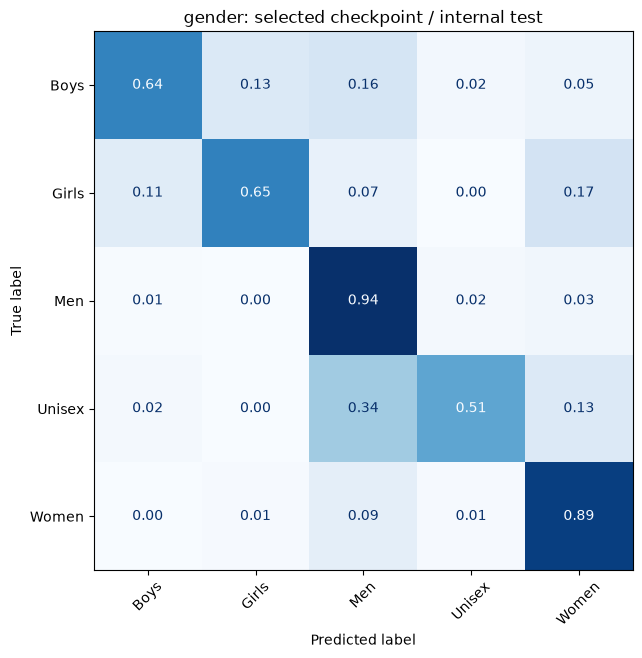

In [31]:
# Gender
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('gender')
result = test_results['gender']
labels = result['labels']
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'], labels=np.arange(len(labels)), display_labels=labels, normalize='true', values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"{'gender'}: selected checkpoint / internal test")

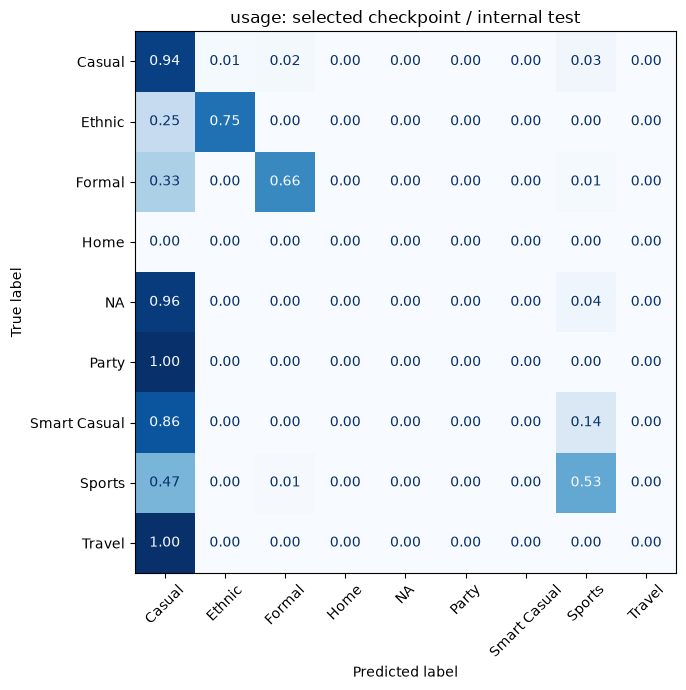

In [32]:
# Occasion (usage)
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()
directory = RESULTS
stem = stem_for('usage')
result = test_results['usage']
labels = result['labels']
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(result['truth'], result['predictions'], labels=np.arange(len(labels)), display_labels=labels, normalize='true', values_format='.2f', xticks_rotation=45, ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"{'usage'}: selected checkpoint / internal test")
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Ultimate Judgement

The final decision compares the best measured configuration within each of the three model families. The tables summarize the restored best-macro-F1 epochs; the decision prioritizes validation macro-F1, then accuracy, then fewer parameters. Internal-test scores are reported only after selection.

**Gender**

| Model family | Training accuracy | Validation accuracy | Training loss | Validation loss | Validation macro-F1 |
|---|---:|---:|---:|---:|---:|
| Shallow MLP | 85.00% | 84.69% | 0.4318 | 0.4602 | 0.7118 |
| Deeper MLP | 84.38% | 83.55% | 0.4324 | 0.4619 | 0.6409 |
| CNN (selected) | 92.60% | 89.93% | 0.2083 | 0.3225 | 0.7901 |


**Occasion**

| Model family | Training accuracy | Validation accuracy | Training loss | Validation loss | Validation macro-F1 |
|---|---:|---:|---:|---:|---:|
| Shallow MLP (selected) | 86.81% | 87.38% | 0.4105 | 0.4874 | 0.4522 |
| Deeper MLP | 84.98% | 85.38% | 0.4974 | 0.4851 | 0.3623 |
| CNN | 95.26% | 89.55% | 0.1803 | 0.3138 | 0.4497 |

Training enables dropout and augmentation, while validation uses inference mode. Training accuracy can therefore be lower than validation accuracy. Weighted CNN training loss and unweighted validation loss use different weighting; their raw gap is not a direct overfitting measure. Continuation histories count additional epochs from the original restored CNN weights. Validation macro-F1 averages only classes with positive ground-truth support.


In [33]:
winner = comparisons['gender'].loc[winners['gender']]
baseline = comparisons['gender'].loc[comparisons['gender']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['gender'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['gender']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['gender']['metrics']['macro_f1']}, name='gender'))
winner = comparisons['usage'].loc[winners['usage']]
baseline = comparisons['usage'].loc[comparisons['usage']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['usage'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['usage']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['usage']['metrics']['macro_f1']}, name='usage'))

selected_method                cnn_four_blocks_scheduled
selection_macro_f1                              0.790123
selection_accuracy                               0.89931
macro_f1_gain_over_baseline                      0.07837
internal_test_accuracy                          0.889122
internal_test_macro_f1                          0.739821
Name: gender, dtype: object

selected_method                shallow_mlp_lower_lr
selection_macro_f1                         0.452185
selection_accuracy                         0.873793
macro_f1_gain_over_baseline                     0.0
internal_test_accuracy                     0.856943
internal_test_macro_f1                     0.374519
Name: usage, dtype: object

### 6.1. Decision Analysis

**Gender: model selection and limitations**

The original scheduled four-block CNN remains selected after tuning. Its **89.93% validation accuracy and 0.7901 macro-F1** exceed the tuned shallow MLP's 84.69% and 0.7118, and the best deeper MLP's 83.55% and 0.6409. The CNN uses **654,021 parameters**, far fewer than either MLP. The shallow MLP benefits from the lower learning rate, but the lower-rate deeper MLP and both CNN continuation trials fail to improve their respective original configurations. Keeping the original CNN is therefore a measured tuning outcome rather than an assumption that the newest run is best.

The CNN's selected epoch records 92.60% training accuracy and 89.93% validation accuracy. This gap is smaller than for article-type classification, but it does not remove class-specific limitations. Men and Women have selection F1 scores of **0.9305 and 0.9066**, whereas Unisex reaches **0.6187** and recalls only **53.42%** of its 161 examples. Girls and Boys have 51 and 75 selection examples, so their estimates are less stable than those of the adult catalogue categories.

These outputs describe the retailer's audience categories for products. They are not an inference of an individual's gender identity. Similar designs can be marketed under different audience categories, so the classifier should support catalogue labelling with review rather than claim universally correct audience assignments.

After model selection, separate calibration and policy groups determine confidence handling. The acceptance rule retains **T=1**, so no temperature adjustment is applied. The internal-test ECE is **0.0217**, NLL is 0.3073, and Brier score is 0.1633. These measure different aspects of probability quality; low aggregate ECE does not guarantee reliable confidence in every class. The saved review threshold is **0.50**, chosen under a 90% accuracy target and minimum 100 policy examples. That policy target is an empirical selection condition, not a guarantee for future images.

The selected `cnn_four_blocks_scheduled` model is saved as **`models/gender_model.keras`**, with label order, preprocessing and confidence metadata. Loading and prediction checks passed. Its descriptive internal-test accuracy is **88.91%** and macro-F1 is **0.7398**. Because the internal test has prior development exposure, these results do not establish independent real-world performance. Public web deployment and the Task 4 submission remain outside the completed validation scope.

**Occasion: model selection and limitations**

The shallow MLP is selected by the predeclared macro-F1 rule, but the evidence is much less decisive than for the other targets. It reaches **0.4522 validation macro-F1**, narrowly above the weighted CNN's **0.4497**, while the deeper MLP reaches only 0.3623. The CNN has higher validation accuracy (**89.55% versus 87.38%**), lower validation loss, and many fewer parameters (**655,049 versus 9,439,753**). Consequently, the MLP does not dominate across evaluation criteria; it wins only the first criterion in the declared ranking.

The difference is particularly sensitive to a rare label. The MLP correctly predicts **2 of 5 literal NA examples**, while the CNN predicts **1 of 5**. CNN has higher F1 on Casual, Ethnic, Formal and Sports. Both models have zero recall for Party, Smart Casual and Travel, whose selection supports are only 1, 4 and 2. Home has no selection examples, meaning the selection macro-F1 covers **8 of 9 output labels**. This makes the 0.0025 macro-F1 margin fragile rather than evidence of broad MLP superiority.

The subsequent internal-test result reinforces the limitation: the selected MLP obtains **85.69% accuracy and 0.3745 macro-F1**, below the initial CNN's 90.14% and 0.4185. This regression is reported openly; it is not used to retrospectively change the validation rule or to claim that the newly tuned CNN was tested. The initial CNN and newly weighted CNN are different candidates. Resolving the ranking would require a separately planned validation study with repeated group-aware splits and adequate minority support.

For the current experiment, the exported artifact follows the declared rule. For practical catalogue use, this is a provisional choice with weak evidence for rare occasions. The large accuracy/macro-F1 difference shows why a high overall score cannot justify broad occasion recognition.

After model selection, separate calibration and policy groups determine confidence handling. The acceptance rule retains **T=1**, so no temperature adjustment is applied. The internal-test ECE is **0.0231**, NLL is 0.4608, and Brier score is 0.2168. These measure different aspects of probability quality; low aggregate ECE does not guarantee reliable confidence in every class. The saved review threshold is **0.56**, chosen under a 90% accuracy target and minimum 100 policy examples. That policy target is an empirical selection condition, not a guarantee for future images.

The selected `shallow_mlp_lower_lr` model is saved as **`models/usage_model.keras`**, with label order, preprocessing and confidence metadata. Loading and prediction checks passed. Its descriptive internal-test accuracy is **85.69%** and macro-F1 is **0.3745**. Because the internal test has prior development exposure, these results do not establish independent real-world performance. Public web deployment and the Task 4 submission remain outside the completed validation scope.


### 6.2. Independent Literature Comparison

[DeepFashion / FashionNet (Liu et al., 2016)](https://openaccess.thecvf.com/content_cvpr_2016/html/Liu_DeepFashion_Powering_Robust_CVPR_2016_paper.html) learns clothing representations with joint attribute and landmark supervision. Our classifiers instead learn separate catalogue targets from whole images without landmark annotations. This is a difference in supervision, not evidence that either approach has higher accuracy on the other's task.

[DeepFashion2 (Ge et al., 2019)](https://arxiv.org/abs/1901.07973) evaluates detection, pose, segmentation and retrieval with richer annotations. Its task definitions and evaluation protocols differ from our audience and occasion classification. We therefore compare design choices and limitations rather than placing these scores in the same accuracy table.


## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.


In [34]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    # Export architecture, learned weights and metadata without optimizer slots.
    inference_model = keras.models.clone_model(model)
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path

In [35]:
stem, method = (stem_for('gender'), winners['gender'])
path = save_checkpoint(checkpoints['gender'], OUTPUT / f'{stem}_model.keras')
histories['gender'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='gender', selected=method, cnn_selected=ranked(tuning['gender']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['gender']['metrics'], split_sizes={name: len(frame) for name, frame in frames['gender'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)
stem, method = (stem_for('usage'), winners['usage'])
path = save_checkpoint(checkpoints['usage'], OUTPUT / f'{stem}_model.keras')
histories['usage'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='usage', selected=method, cnn_selected=ranked(tuning['usage']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['usage']['metrics'], split_sizes={name: len(frame) for name, frame in frames['usage'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/gender_model.keras


Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/usage_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [36]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [37]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('gender')}_model.keras")
with Image.open(frames['gender']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))
predictor = FashionClassifier(OUTPUT / f"{stem_for('usage')}_model.keras")
with Image.open(frames['usage']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))

{'target': 'gender', 'label': 'Women', 'confidence': 0.7199444361249494, 'top_k': [{'label': 'Women', 'confidence': 0.7199444361249494}, {'label': 'Men', 'confidence': 0.22724404029569112}, {'label': 'Unisex', 'confidence': 0.05120900778495756}], 'needs_review': False, 'review_threshold': 0.5, 'confidence_calibrated': False}


{'target': 'usage', 'label': 'Sports', 'confidence': 0.9324994037681789, 'top_k': [{'label': 'Sports', 'confidence': 0.9324994037681789}, {'label': 'Casual', 'confidence': 0.06737449100602838}, {'label': 'Ethnic', 'confidence': 6.173456523976084e-05}], 'needs_review': False, 'review_threshold': 0.56, 'confidence_calibrated': False}


## 8. Conclusion

### 8.1. Gender

This task compared a shallow MLP baseline, a deeper MLP and CNN configurations using RGB images, shared preprocessing and frozen product-group partitions. Training-only statistics and separate selection, calibration and policy groups limit leakage between fitting and evaluation. The experiment tests the supplied catalogue labels; it does not establish performance on arbitrary consumer photographs.

The selected model is **`cnn_four_blocks_scheduled`**. Its internal-test accuracy of **88.91%** and macro-F1 of **0.7398** describe the final exported classifier, while the validation comparison above explains why it was selected. The result supports this configuration over the alternatives tested here, while the remaining class-wise errors prevent a claim of uniformly reliable recognition.

**Key insights**

- The original CNN remains best after additional trials, demonstrating that unsuccessful tuning provides evidence for retaining a model.
- The tuned shallow MLP is a stronger dense baseline than the deeper MLP; layer count alone does not predict validation quality.
- Strong adult-category scores do not establish equally reliable performance on Unisex, Girls and Boys catalogue labels.

**Practical outcome and next steps.** The trained classifier is exported and can be loaded by the prediction scripts without retraining. Further work should examine the annotation consistency and support of smaller catalogue categories, and test the model on independently collected product groups. Human review remains appropriate for ambiguous audience labels. No course-test submission or public-deployment validation is claimed in this notebook.

### 8.2. Occasion

This task compared a shallow MLP baseline, a deeper MLP and CNN configurations using RGB images, shared preprocessing and frozen product-group partitions. Training-only statistics and separate selection, calibration and policy groups limit leakage between fitting and evaluation. The experiment tests the supplied catalogue labels; it does not establish performance on arbitrary consumer photographs.

The selected model is **`shallow_mlp_lower_lr`**. Its internal-test accuracy of **85.69%** and macro-F1 of **0.3745** describe the final exported classifier, while the validation comparison above explains why it was selected. For occasion, the narrow validation margin and internal-test regression make the choice provisional. The CNN remains competitive and is stronger on the common classes; a robust follow-up evaluation is needed before claiming that MLP is generally better.

**Key insights**

- The highest-accuracy candidate need not win a macro-F1-based comparison; the chosen metric determines the trade-off.
- A single additional correct prediction in a tiny class can change the ranking, so class support is essential when interpreting macro-F1.
- The selected MLP regresses on the descriptive internal test. This is a limitation of the selection evidence, not a result to hide or a reason to tune against that test.

**Practical outcome and next steps.** The trained classifier is exported and can be loaded by the prediction scripts without retraining. The next priority is a more stable group-aware validation design for rare occasions rather than further tuning against the exposed internal test. Repeated runs should establish whether the MLP/CNN ordering persists, while annotation review should clarify the meaning of literal NA and ambiguous occasions. No course-test submission or public-deployment validation is claimed in this notebook.
